# # Customer Churn Analysis for Subscription Business

## Problem Statement
A telecom subscription company is facing customer churn. Customer churn means customers stop using the service. This affects company revenue and growth.

### Objective
To identify factors responsible for customer churn and suggest business recommendations to improve customer retention.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

In [6]:
import os

print(os.getcwd())

c:\Users\nidhi\OneDrive\Desktop\Customer churn


In [7]:
import os

print(os.listdir())

['customer churn.ipynb', 'customer_churn_dataset.csv']


In [8]:
df=pd.read_csv("customer_churn_dataset.csv")
df.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [9]:
#Overview 
print("Shape:",df.shape)
df.info()
df.describe()

Shape: (20000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20000 non-null  int64  
 1   tenure            20000 non-null  int64  
 2   monthly_charges   20000 non-null  float64
 3   total_charges     20000 non-null  float64
 4   contract          20000 non-null  object 
 5   payment_method    20000 non-null  object 
 6   internet_service  17987 non-null  object 
 7   tech_support      20000 non-null  object 
 8   online_security   20000 non-null  object 
 9   support_calls     20000 non-null  int64  
 10  churn             20000 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 1.7+ MB


,customer_id,tenure,monthly_charges,total_charges,support_calls
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,10000.500000,36.467450,70.010531,2543.979209,1.51255
std,5773.647028,20.773984,28.890239,1882.949804,1.23524
min,1.000000,1.000000,20.000000,20.230000,0.00000
25%,5000.750000,18.000000,45.210000,1045.837500,1.00000
50%,10000.500000,36.000000,70.090000,2096.495000,1.00000
75%,15000.250000,54.000000,95.072500,3690.337500,2.00000
max,20000.000000,72.000000,120.000000,8629.920000,8.00000


In [11]:
print(df.columns)

Index(['customer_id', 'tenure', 'monthly_charges', 'total_charges', 'contract',
       'payment_method', 'internet_service', 'tech_support', 'online_security',
       'support_calls', 'churn'],
      dtype='object')


In [12]:
#problem identification
df["churn"].value_counts()

churn
No     13157
Yes     6843
Name: count, dtype: int64

In [13]:
df["churn"].value_counts(normalize=True)*100

churn
No     65.785
Yes    34.215
Name: proportion, dtype: float64

In [14]:
#Checking data quality
df.isnull().sum()

customer_id            0
tenure                 0
monthly_charges        0
total_charges          0
contract               0
payment_method         0
internet_service    2013
tech_support           0
online_security        0
support_calls          0
churn                  0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.nunique()

customer_id         20000
tenure                 72
monthly_charges      8639
total_charges       18956
contract                3
payment_method          4
internet_service        2
tech_support            2
online_security         2
support_calls           9
churn                   2
dtype: int64

In [19]:
#Clean Data
df["total_charges"] = pd.to_numeric(
    df["total_charges"],
    errors="coerce"
)

In [20]:
df["total_charges"].fillna(
    df["total_charges"].median(),
    inplace=True
)

C:\Users\nidhi\AppData\Local\Temp\ipykernel_1604\3641235609.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_charges"].fillna(


In [21]:
df = df.drop_duplicates()

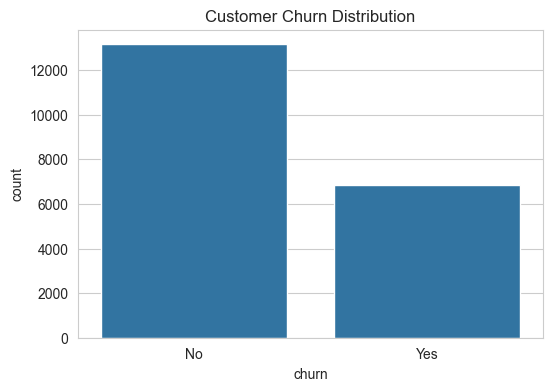

In [22]:
#Churn Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

### Observation
Most customers stay with the company, but a significant percentage churn.
Customer churn is an important business problem.

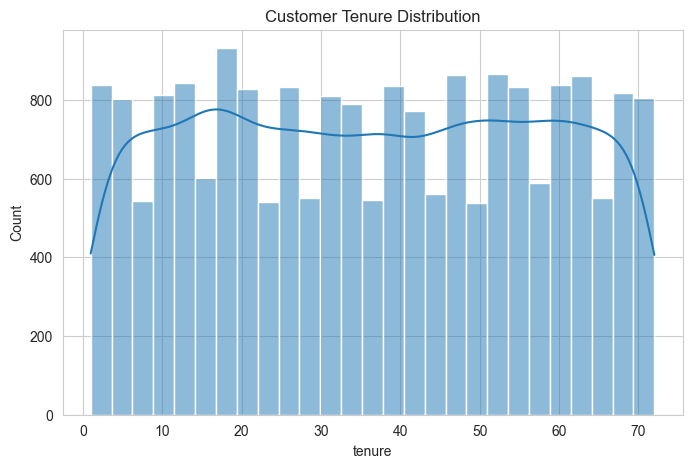

In [23]:
#Tenure Analysis
plt.figure(figsize=(8,5))
sns.histplot(
    df["tenure"],
    kde=True
)
plt.title("Customer Tenure Distribution")
plt.show()

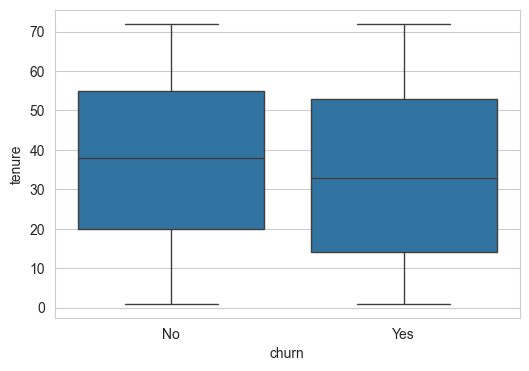

In [24]:
#Churn Vs Tenure
plt.figure(figsize=(6,4))
sns.boxplot(
    x="churn",
    y="tenure",
    data=df
)
plt.show()

### Insight
Customers with lower tenure are more likely to churn.

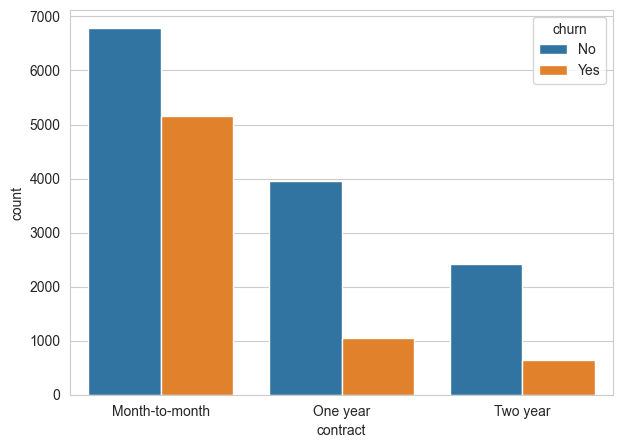

In [25]:
#Contract type 
plt.figure(figsize=(7,5))
sns.countplot(
    x="contract",
    hue="churn",
    data=df
)
plt.show()

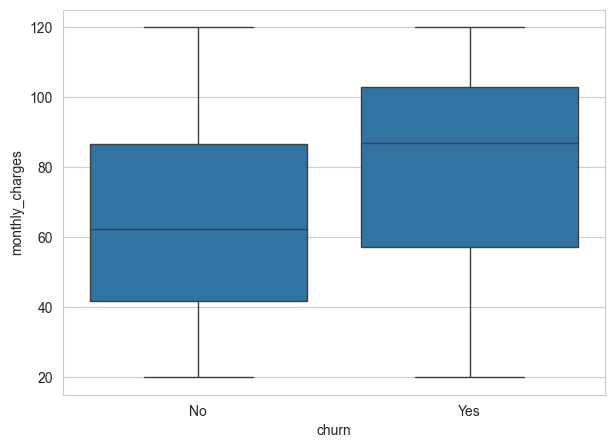

In [26]:
#Monthly Charges
plt.figure(figsize=(7,5))
sns.boxplot(
    x="churn",
    y="monthly_charges",
    data=df
)
plt.show()

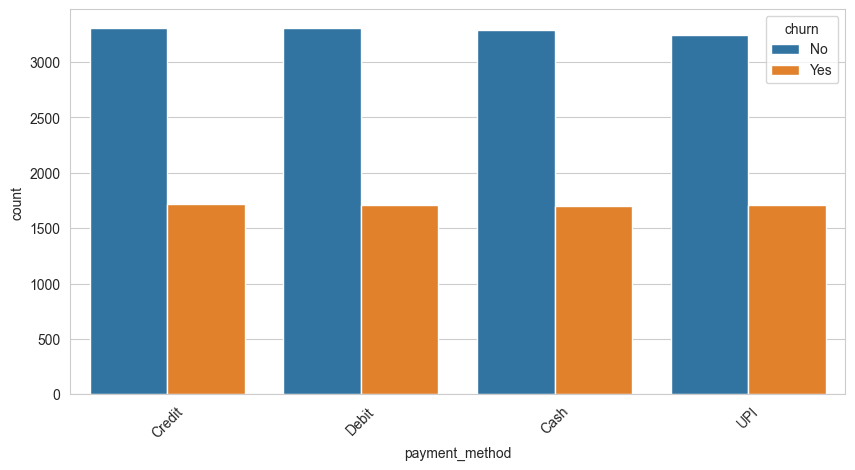

In [27]:
#Payment Method Analysis
plt.figure(figsize=(10,5))
sns.countplot(
    x="payment_method",
    hue="churn",
    data=df
)
plt.xticks(rotation=45)
plt.show()

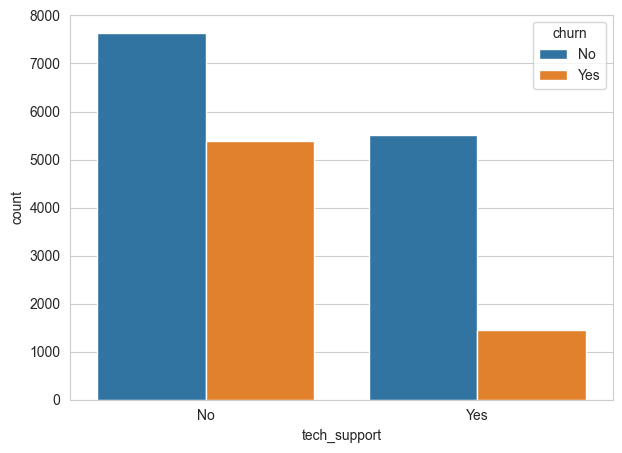

In [28]:
#Tech Support Analysis
plt.figure(figsize=(7,5))
sns.countplot(
    x="tech_support",
    hue="churn",
    data=df
)
plt.show()

In [29]:
#Feature Engineering
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,12,36,72],
    labels=[
        "New",
        "Medium",
        "LongTerm"
    ]
)

In [30]:
df["high_monthly_charge"] = (
    df["monthly_charges"]
    >
    df["monthly_charges"].median()
).astype(int)

In [31]:
df["autoPay"] = (
    df["payment_method"]
    .str.contains(
        "automatic",
        case=False
    )
).astype(int)

In [32]:
#Heatmap
df["churn_flag"] = df["churn"].map(
    {
        "Yes":1,
        "No":0
    }
)

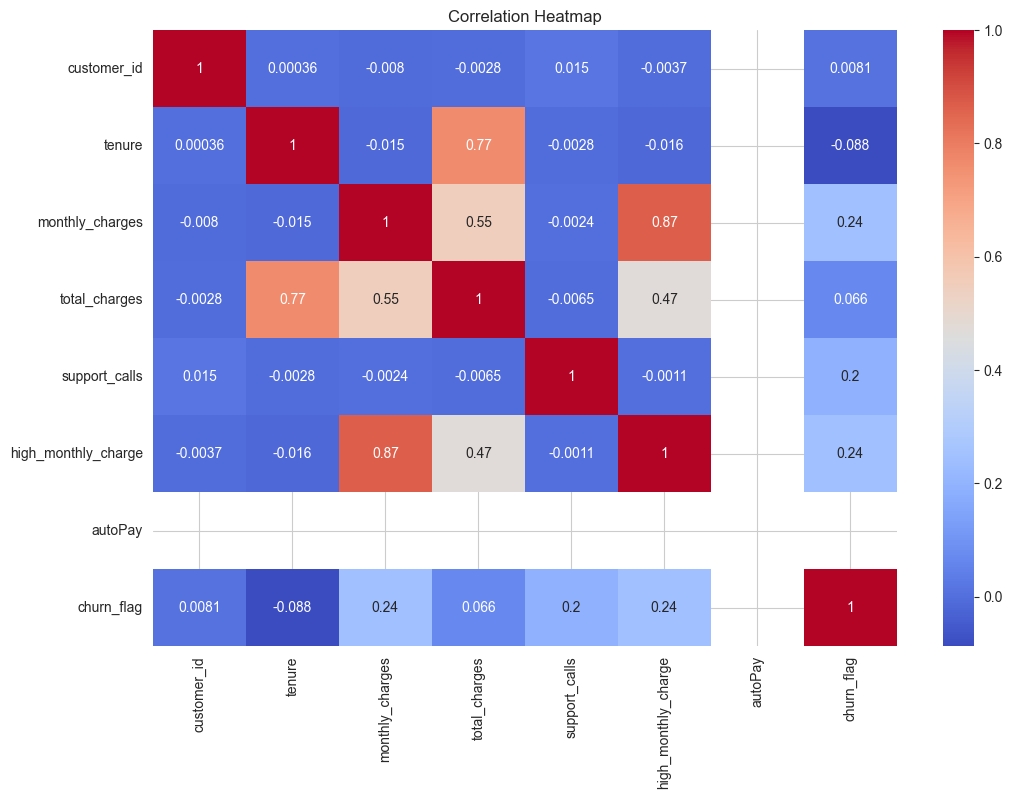

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

# Business Insights
1. Month-to-month customers have the highest churn.

2. Customers with low tenure leave more frequently.

3. High monthly charges increase churn probability.

4. Customers without tech support are at higher risk.

5. Electronic check users churn more than auto-payment users.

In [35]:
# Save Cleaned Dataset

df.to_csv(
    "Cleaned_Customer_Churn_Dataset_Nidhi_Sandbhor.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
